# Final Project PART 2: Indexing and Evaluation

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Indexing

### Inverted Index

The first step of this delivery is to create the **inverted index**. According to the last part of the project, we want to create the index in the following format:

```json
inverted_index =  {
    "term1": {
        "field1": [docID, [pos1, pos2]],
        "field2": [docID, [pos1]],
        ...
    },
    "term2": {
        "field2": [docID, [pos1, pos2]],
        ...
    },
    ...
}
```

Where we have sub indices for each term, where we keep record of where the `term` is found in the document in terms of the `field` ("category", "brand", "title_description", etc.).

Additionally, knowing that we are gonna use a TF-IDF ranking, we are gonna compute and store in the same function `create_index_tf_idf`, the `tf` (term frequency), `df` (document frequency), and `idf` (inverse document frequency) for later computationsa as it is worth it to iterate over the `corpus` only once.

To compute the mentioned metrics, we need to take into account the structure of our index. We constructed it so that we could apply weights to terms in different fields. For instance, give more relevance to a term appearing in the field `category`, than that same term appearing in the field `product_details`. With this goal, we need to compute the TF-IDF in the following way: $$\text{TF-IDF}(t,d)=IDF_t · \sum_{f\in F}{w_f · TF_{t,f,d}}$$

+ $\text{TF}_{t,f,d}$: frequency of term $t$ in field $f$ of document $d$
+ $\text{IDF}_t$: computed globally for term $t$
+ $w_f$: the weight assigned to field $f$
+ $F$: set of fields in which term $t$ appears in document $d$

We consider each field in the document as a separate text region with its own frequency behaviour.

Then, to store the `df`, `tf`, and `idf` during the computation of the index, we are gonna create three extra dictionaries:

```python
df = {
    "term1": df1,
    "term2": df2,
    ...
}

idf = {
    "term1": idf1,
    "term2": idf2,
    ...
}

tf = {
    "doc1": {
        "term1": {
        "field1": tf1,
        "field2": tf2,
        ...
        },
        "term2": {
            "field1": tf3,
            ...
        },
        ...
    },
    "doc2": {...},
    ...    
}
```

And then, the computation of the TF-IDF will be as follows:

```python
# Compute the tf per term
tf[term] = 0
for field in list_of_fields:
    tf[term] += weigths[field] * tf[term][field]

# Compute the tf-idf
tf_idf[term] = idf[term] * tf[term]
```

Where we compute for all `term`s in the inverted index, and `tf` should be normalized in the computation of `tf_idf`.

The computation of the index and the `tf`, `df`, and `idf` are made in the following function:

In [ ]:
def create_index_tf_idf():
    return True

### Weights assignment

To know what weights to assign to each field in the document, we started by using a weight of `1.0` for all fields, and compared the ranking results for the various queries we decided. In this way, we empirically chose specific weights for the fields.

The used queries are:

In [ ]:
queries = ["red mini dress with puff sleeves",  # specific query
           "breathable running shirts",         # product description query
           "gym clothes hot weather men",       # occasion-based query
           "accessories for long dress",        # searching for accessories
           "jackets to wear over crop tops"]    # related products query

### Ranking

To implement the ranking, we based the functions in the Practice Session 1 code. We created a `rank_tf_idf` function that generates the ranking given some documents and the inverted index. But the ranking is not done for all documents in the corpus. First, we have a `search` function that given the corpus and a query, it selects only the documents that contain ALL query terms, and then computes the ranking with them. The functions are the following:

In [2]:
def rank_tf_idf():
    return True

In [4]:
def search():
    return True

## Evaluation

For the evaluation, we are gonna compute the following evaluation metrics:
+ Precision@K (P@K)
+ Recall@K (R@K)
+ Average Precision@K (AP@K)
+ F1-Score@K
+ Mean Average Precision (MAP)
+ Mean Reciprocal Rank (MRR)
+ Normalized Discounted Cumulative Gain (NDCG)

The following functions are based on the code from Practice Session 2.

The queries from which we obtain the results are:

In [19]:
query1 = "women full sleeve sweatshirt cotton"
query2 = "men slim jeans blue"

given_queries = [query1, query2]

### Create evaluation metric functions and evaluate given queries

#### Load the `validation_labels.csv`

In [14]:
search_results = pd.read_csv("../../data/validation_labels.csv")
display(search_results.head())
print_result = search_results["labels"].unique()
print("The ground truth of our dataset is composed of {} Relevance Levels: {}".format(len(print_result), sorted(print_result)))

,title,pid,query_id,labels
0,Full Sleeve Printed Women Sweatshirt,SWSFFVKBCQG5FHPF,1,1
1,Full Sleeve Striped Women Sweatshirt,SWSFJY5ZFHQ7HXKW,1,0
2,Full Sleeve Printed Women Sweatshirt,SWSFUY89NHMZHZPX,1,1
3,Full Sleeve Graphic Print Women Sweatshirt,SWSFXQ5YX6RZKHP4,1,1
4,Full Sleeve Solid Women Sweatshirt,JCKFTZBC3DMCVYXH,1,0


The ground truth of our dataset is composed of 2 Relevance Levels: [np.int64(0), np.int64(1)]


We can see how all the documents are labeled as either **relevant** or **not relevant**. We are also considering that the documents are given, for each query, in the ranking order the system retrieved them.

#### P@K and R@K

$$
P = \frac{\text{\# retrieved relevant items}}{\text{\# retrieved items}}
$$
$$
R = \frac{\text{\# retrieved relevant items}}{\text{\# relevant items}}
$$

In [ ]:
def precision_at_k(query_results, k=10):
    '''
    Returns the precision@k for the top k documents in the results

    :param query_results: dataframe with the results (sorted) of a specific query
    :param k: number of documents to consider
    :return precision_at_k: return the precision of the top k
    '''
    top_k = query_results.head(k)
    n_relevant_retrieved = top_k['labels'].sum()
    return n_relevant_retrieved/k

In [18]:
def recall_at_k(query_results, k=10):
    '''
    Returns the recall@k for the top k documents in the results

    :param query_results: dataframe with the results (sorted) of a specific query
    :param k: number of documents to consider
    :return recall_at_k: return the precision of the top k
    '''
    top_k = query_results.head(k)
    n_relevant_retrieved = top_k['labels'].sum()
    n_relevant = query_results['labels'].sum()
    return n_relevant_retrieved/n_relevant

#### Average Precision@K

$$
AP@K = \frac{1}{GTP} \sum_k^n{P@K \times rel@K}
$$

+ $GTP$: total number of ground truth positives, within the retrieved $K$
+ $P@K$: precision at $K$ ranked results
+ $rel@K$: relevance function (retrieves 1 if the document at rank $K$ is relevent or 0 otherwise)

In [58]:
def avg_precision_at_k(query_results, k):
    '''
    Returns the approximate area under the un-interpolated precision-recall curve.

    :param query_results: dataframe with the results (sorted) of a specific query
    :param k: number of documents to consider
    :return avg_P@k: average precision at k
    '''
    top_k = query_results.head(k)
    GTP = top_k['labels'].sum()
    sum = 0
    for curr_k in range(k):
        label_k = query_results.iloc[curr_k]['labels']
        sum += precision_at_k(query_results, k) * label_k
    
    return ((1/GTP)*sum)

#### F1-score@k

$$
F = \frac{1}{\frac{1}{2}(\frac{1}{R}+\frac{1}{P})} = \frac{2RP}{R+P}
$$

+ $R$: $R@K$
+ $P$: $P@K$

In [109]:
def f1_score_at_k(query_results, k):
    '''
    Returns the harmonic mean of rank at k and precision at k

    :param query_results: results of a search for one query
    :param k: top k for which to compute f1 score
    :return: f1 score for query results
    '''
    P_at_k = precision_at_k(query_results, k)
    R_at_k = recall_at_k(query_results, k)

    return (2*R_at_k*P_at_k/(R_at_k+P_at_k))

#### Mean Average Precision (MAP)

$$
MAP = \frac{1}{N} \sum_{i=1}^n{AP_i}
$$

+ $N$: number of queries
+ $AP_i$: average precision of query $i$

In [108]:
def map_at_k(results,k):
    '''
    Returns the average area under the precision-recall curve for a set of queries at top k

    :param results: results of validation for all queries
    :param k: k at which to evaluate map
    :return: mean average precision at k
    '''
    queries_ids = search_results['query_id'].unique().tolist()
    N = len(queries_ids)
    sum = 0
    for id in queries_ids:
        query_results = results[results['query_id'] == id]
        k_top = query_results.head(k)
        sum += avg_precision_at_k(k_top, k=len(k_top))

    return ((1/N)*sum)

#### Mean Reciprocal Rank (MRR)

$$
MRR(R_i) = \frac{1}{N} \sum_{i=1}^N{RR(R_i)}
$$

$$
RR(R_i) =
\begin{cases}
\frac{1}{S_{\text{correct}}(R_i)}, & \text{if } S_{\text{correct}}(R_i) \leq K \\
0, & \text{otherwise}
\end{cases}
$$

+ $R_i$: the ranking for query $q_i$
+ $S_{correct}(R_i)$: position of the first correct answer in $R_i$
+ $K$: threshold for ranking position
+ $N$: total number of queries (and rankings, since we have a ranking per query)

In [110]:
def rr_at_k(query_results, k):
    '''
    Returns the Reciprocal Rank for the given search results

    :param query_results: dataframe with the query results
    :param k: k of top-k for which to compute mean reciprocal rank
    :return: mean reciprocal rank for the results
    '''
    
    top_k_labels = query_results.head(k)['labels']
    S_correct = np.argmax(top_k_labels>0) + 1

    return (1/S_correct)


In [120]:
def mrr(results, k):
    '''
    Compute the mean reciprocal rank for a given search results

    :param results: dataframe with the ranking results from various queries
    :param k: up to which k consider the reciprocal rank
    :return: Mean Reciprocal Rank
    '''
    query_ids = results['query_id'].unique().tolist()

    rr = []
    for id in query_ids:
        query_results = results[results['query_id'] == id]
        rr.append(rr_at_k(query_results, k))
    mrr = float(sum(rr)) / len(rr)

    return mrr

#### Normalized Discounted Cumulative Gain (NDCG)

$$
NDCG = \frac{DCG}{IDCG}
$$

$$
DCG = \sum_{pos=1}^n{\frac{rel_{pos}}{\log_2{(pos+1)}}}
$$

$$
IDCG = \sum_{pos=1}^{|rel_n|}{\frac{rel_{pos}}{\log_2{(pos+1)}}}
$$

+ $DCG$: Discounted Cumulative Gain
+ $IDCG$: Ideal Discounted Cumulative Gain
+ $rel_pos$: relevance of document at rank $pos$
+ $rel_n$: list of relevant documents (ordered by relevance) in the corpus up to rank $n$

In [131]:
def dcg_at_k(query_results, k):
    '''
    Computes the DCG for a query ranking results up to k

    :param query_results: dataframe of search results for one query
    :param k: up to which rank k to compute dcg
    :return: discounted cumulative gain at k
    '''
    top_k = query_results.head(k)
    rel = top_k['labels']
    discounts = np.log2(np.arange(1, len(rel) + 1) + 1)
    dcg = np.sum(rel/discounts)
    return dcg

In [133]:
def ndcg_at_k(query_results, k):
    '''
    Computes the NDCG for a query ranking results up to k

    :param query_results: dataframe of search results for one query
    :param k: up to which rank k to compute dcg
    :return: normalized discounted cumulative gain at k
    '''
    dcg = dcg_at_k(query_results, k)
    idcg = dcg_at_k(query_results.sort_values(by='labels', ascending=False), k)

    return dcg / idcg if idcg > 0 else 0.0

#### Applying the evaluation metrics

In [101]:
# Compute the Precision-Recall curve for both queries
def get_precision_recall_curve(query_results):
    '''
    Plots the precision recall graph for a given query

    :param query_results: results from a given query
    :return precision and recall: returns the arrays for the precision and recall at each k
    '''
    n_top_k = len(query_results)
    precision = []
    recall = []
    f1 = []
    for k in range(1,n_top_k+1):
        precision.append(precision_at_k(query_results, k))
        recall.append(recall_at_k(query_results, k))
        f1.append(f1_score_at_k(query_results, k))
    return precision, recall, f1

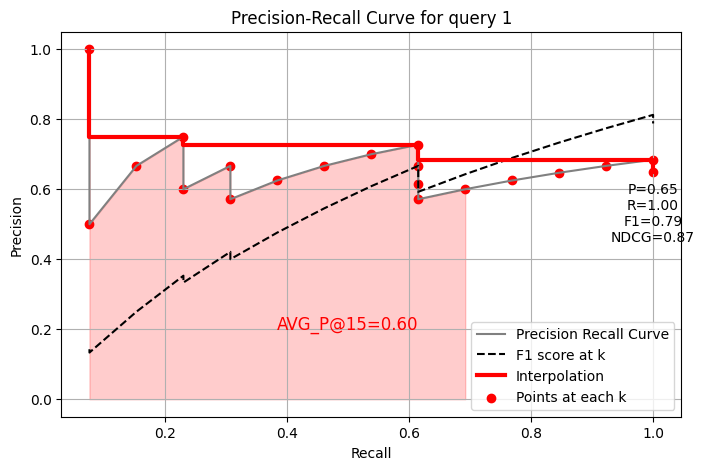

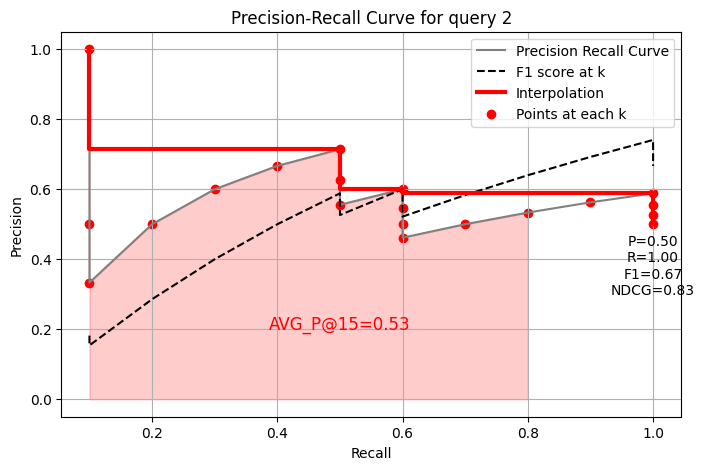

In [134]:
queries_ids = search_results['query_id'].unique().tolist()
k = 15
for query_id in queries_ids:
    # Get results for query, and compute precision and recall at every k
    query_results = search_results[search_results['query_id'] == query_id]
    precision, recall, f1 = get_precision_recall_curve(query_results)

    # Get final precision and recall
    final_precision = precision[-1]
    final_recall = recall[-1]
    final_f1 = f1[-1]

    # Get NDCG
    ndcg = ndcg_at_k(query_results, k=len(query_results))

    # Compute precision steps for interpolation line    
    precision_step = np.maximum.accumulate(precision[::-1])[::-1]

    # Compute average precision at k
    avg_p_k = avg_precision_at_k(query_results, k=k)

    plt.figure(figsize=(8, 5))
    plt.plot(recall, precision, label='Precision Recall Curve', color="grey")
    plt.plot(recall, f1, label='F1 score at k', color="black", linestyle="--")
    plt.step(recall, precision_step, where='post', label='Interpolation', color='red', linewidth=3)
    plt.scatter(recall, precision, color='red', label='Points at each k')

    # Fill area under the stepwise curve to show average precision at k
    plt.fill_between(recall[:k], precision[:k], 0, alpha=0.2, color='red')

    # Annotate average precision@k
    plt.text(0.5, 0.2, f'AVG_P@{k}={avg_p_k:.2f}', fontsize=12, color='red', ha='center')

    # Annotate final point
    plt.text(final_recall, final_precision - 0.2,
            f'P={final_precision:.2f}\nR={final_recall:.2f}\nF1={final_f1:.2f}\nNDCG={ndcg:.2f}',
            fontsize=10, color='black', ha='center')

    plt.title(f"Precision-Recall Curve for query {query_id}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.show()

In [135]:
k = 15
mean_avg_precision_k = map_at_k(search_results, k)
mean_reciprocal_rank = mrr(search_results, k)
print(f"map_at_k = {mean_avg_precision_k:.3f}")
print(f"mrr_at_k = {mean_reciprocal_rank:.3f}")

map_at_k = 0.567
mrr_at_k = 1.000


### Evaluate our queries and the ranking results

#### Create the csv with our results labeled as relevant and non-relevant

#### Evaluation with evaluation metrics